# SQL E-commerce Revenue Analysis

## Intro and scope

This notebook describes gross sales patterns in BigQuery's public
`bigquery-public-data.thelook_ecommerce` dataset along three axes:
first vs repeat orders, product category, and item price band.
Only orders with `orders.status = 'Complete'` are included in the source SQL.

**First Order** is each user's earliest observed completed order, ordered by
`created_at, order_id`. **Repeat Order** is any subsequent observed completed
order for that user. This is not necessarily the user's first-ever purchase.

| Metric | Definition |
| --- | --- |
| `gross_sales` | `SUM(order_items.sale_price)`, in USD |
| `item_count` | Number of order-item rows |
| `order_count` | Distinct completed orders represented in the group |
| `user_count` | Distinct users represented in the order-stage group |
| `avg_order_value` (AOV) | `gross_sales / order_count`, for complete order-stage baskets |
| `avg_item_price` | `gross_sales / item_count`, an item-level average, distinct from AOV |
| `avg_items_per_order` | `item_count / order_count` within the group |

The three user-supplied aggregate CSV exports in `data/` are the authoritative
inputs for this publication refresh. The corresponding definitions are in
`sql/01_first_vs_repeat_orders.sql`, `sql/02_category_analysis.sql`, and
`sql/03_price_analysis.sql`. BigQuery was not rerun for this refresh.
The exports do not include an extraction timestamp or observation-window bounds.
Gross sales do not measure profit or margin.

## Load aggregate exports

Run all cells from the notebook directory or repository root with pandas and
matplotlib installed. Charts are saved in `images/`.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from IPython.display import display, Markdown

ROOT = Path.cwd() if (Path.cwd() / 'data').is_dir() else Path.cwd().parent
DATA = ROOT / 'data'
IMAGES = ROOT / 'images'
IMAGES.mkdir(exist_ok=True)

stage = pd.read_csv(DATA / 'first_vs_repeat_orders.csv')
category = pd.read_csv(DATA / 'category_analysis.csv')
price = pd.read_csv(DATA / 'price_analysis.csv')
stage = stage.set_index('order_stage').loc[['First Order', 'Repeat Order']].reset_index()
price = price.set_index('price_band').loc[['Low', 'Mid', 'High']].reset_index()

pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_rows = 30
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

### Aggregate consistency checks

These checks compare the supplied exports and their metric arithmetic. They do
not revalidate source joins, order sequencing, missing item prices, or category
mapping in BigQuery. Category and price-band order counts overlap across groups
and must not be summed to obtain total orders. Order-stage user counts also
overlap: users with repeat activity are included among first-order users.

In [2]:
for frame, key in [(stage, 'order_stage'), (category, 'category'), (price, 'price_band')]:
    assert frame[key].is_unique and not frame.isna().any().any()
    for count in ['item_count', 'order_count']:
        assert (frame[count] > 0).all() and (frame[count] % 1 == 0).all()
    assert np.allclose(frame['gross_sales'] / frame['item_count'], frame['avg_item_price'])
    assert np.allclose(frame['item_count'] / frame['order_count'], frame['avg_items_per_order'])
assert np.allclose(stage['gross_sales'] / stage['order_count'], stage['avg_order_value'])
assert stage.loc[0, 'user_count'] == stage.loc[0, 'order_count']
assert stage.loc[1, 'user_count'] <= stage.loc[1, 'order_count']
for frame in [category, price]:
    assert frame['item_count'].sum() == stage['item_count'].sum()
    assert np.isclose(frame['gross_sales'].sum(), stage['gross_sales'].sum(), rtol=0, atol=0.01)
print(f"Exports reconcile: {stage['order_count'].sum():,} completed orders, "
      f"{stage['item_count'].sum():,} items, USD {stage['gross_sales'].sum():,.2f} gross sales.")

Exports reconcile: 31,166 completed orders, 45,245 items, USD 2,701,655.16 gross sales.


In [3]:
def chart(frame, label, metric, title, filename, horizontal=False):
    data = frame.sort_values(metric, ascending=True) if horizontal else frame
    fig, ax = plt.subplots(figsize=(10, 9) if horizontal else (7, 4.5))
    if horizontal:
        bars = ax.barh(data[label], data[metric], color='#4472A5')
        ax.set_xlabel('Gross sales (USD)' if metric == 'gross_sales' else 'Item count')
        ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
        ax.set_xlim(0, data[metric].max() * 1.23)
        ax.tick_params(axis='y', labelsize=10)
    else:
        bars = ax.bar(data[label], data[metric], color='#4472A5', width=0.6)
        ax.set_ylabel('Gross sales (USD)' if metric == 'gross_sales' else metric.replace('_', ' ').capitalize())
        ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
        ax.set_ylim(0, data[metric].max() * 1.18)
    ax.bar_label(bars, labels=[f'{value:,.0f}' for value in data[metric]], padding=4, fontsize=9)
    ax.set_title(title + '\nCompleted orders only', pad=14)
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    fig.savefig(IMAGES / filename, dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(fig)

## First-order vs Repeat-order analysis

Compare completed order counts and gross sales, then distinguish basket value
(AOV), basket size (items per order), and average item price.

,order_stage,user_count,order_count,item_count,gross_sales,avg_order_value,avg_items_per_order,avg_item_price
0,First Order,27511,27511,39879,"2,379,423.63",86.49,1.45,59.67
1,Repeat Order,3316,3655,5366,"322,231.53",88.16,1.47,60.05


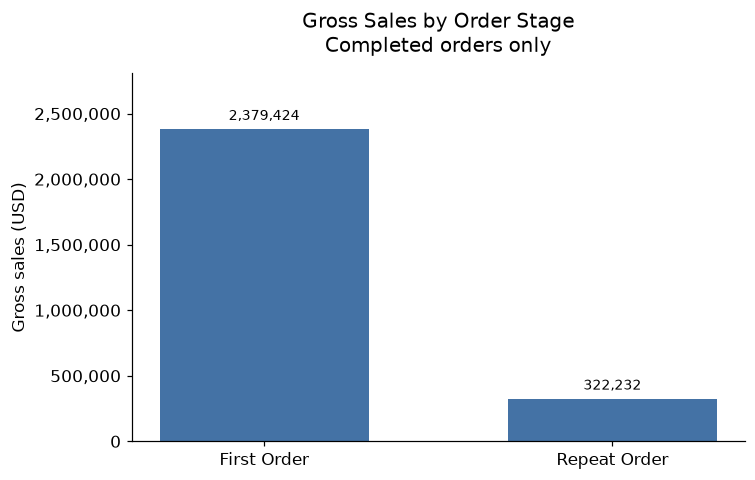

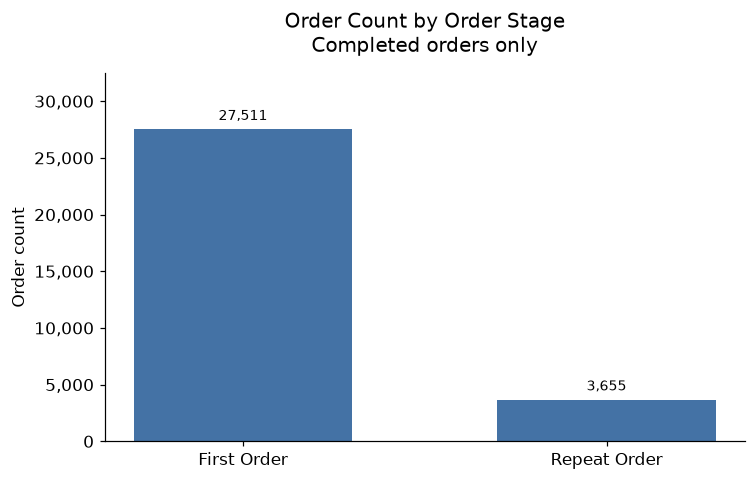

In [4]:
display(stage)
chart(stage, 'order_stage', 'gross_sales', 'Gross Sales by Order Stage', 'gross_sales_by_order_stage.png')
chart(stage, 'order_stage', 'order_count', 'Order Count by Order Stage', 'order_count_by_order_stage.png')

In [5]:
first, repeat = stage.iloc[0], stage.iloc[1]
display(Markdown(
    f"First orders generated **USD {first.gross_sales:,.2f}** across **{int(first.order_count):,} orders**. "
    f"Repeat orders generated **USD {repeat.gross_sales:,.2f}** across **{int(repeat.order_count):,} orders** "
    f"from **{int(repeat.user_count):,} users**.\n\n"
    f"The averages are very similar: first vs repeat AOV is **USD {first.avg_order_value:.2f} vs "
    f"{repeat.avg_order_value:.2f}**, items per order **{first.avg_items_per_order:.2f} vs "
    f"{repeat.avg_items_per_order:.2f}**, and average item price **USD {first.avg_item_price:.2f} vs "
    f"{repeat.avg_item_price:.2f}**. Repeat activity is present without a large difference in these "
    "basket averages. These aggregates do not establish identical basket distributions. "
    "Repeat-order or repeat-user shares are not retention rates: observation windows differ across users."
))

First orders generated **USD 2,379,423.63** across **27,511 orders**. Repeat orders generated **USD 322,231.53** across **3,655 orders** from **3,316 users**.

The averages are very similar: first vs repeat AOV is **USD 86.49 vs 88.16**, items per order **1.45 vs 1.47**, and average item price **USD 59.67 vs 60.05**. Repeat activity is present without a large difference in these basket averages. These aggregates do not establish identical basket distributions. Repeat-order or repeat-user shares are not retention rates: observation windows differ across users.

## Category analysis

`item_count`, `order_count`, `gross_sales`, and `avg_item_price` describe each
category's item volume, order coverage, sales, and item value. Category
`order_count` is non-additive because orders can contain multiple categories.
Category sales divided by category order count would describe only that
category's contribution, not the full basket AOV.

,category,item_count,order_count,gross_sales,avg_item_price,avg_items_per_order
0,Outerwear & Coats,2269,2219,"337,446.84",148.72,1.02
1,Jeans,3203,3085,"307,785.32",96.09,1.04
2,Sweaters,2821,2737,"212,668.77",75.39,1.03
3,Fashion Hoodies & Sweatshirts,3011,2923,"164,373.95",54.59,1.03
4,Swim,2822,2746,"161,946.45",57.39,1.03
5,Suits & Sport Coats,1268,1242,"157,962.51",124.58,1.02
6,Sleep & Lounge,2782,2705,"135,614.63",48.75,1.03
7,Shorts,2815,2733,"132,179.76",46.96,1.03
8,Tops & Tees,3010,2915,"125,299.23",41.63,1.03
9,Active,2304,2249,"116,848.11",50.72,1.02


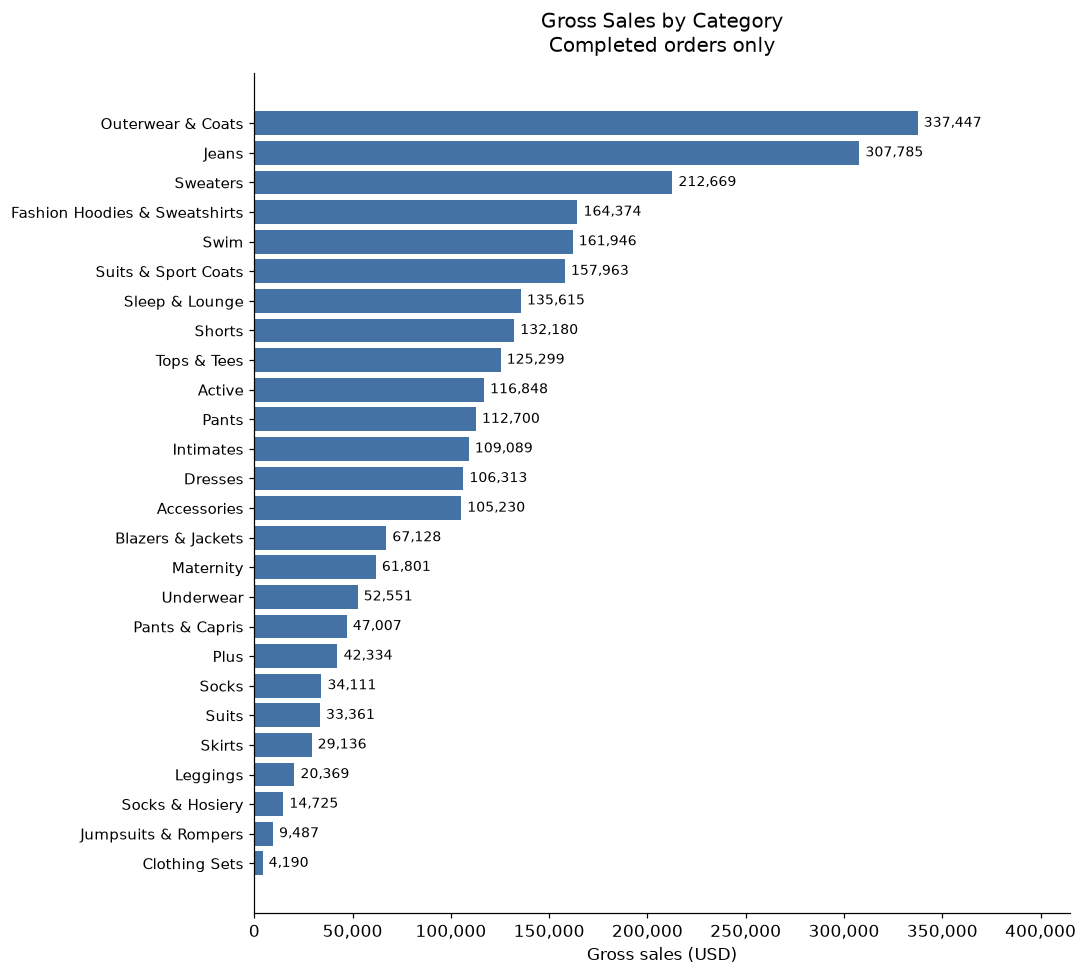

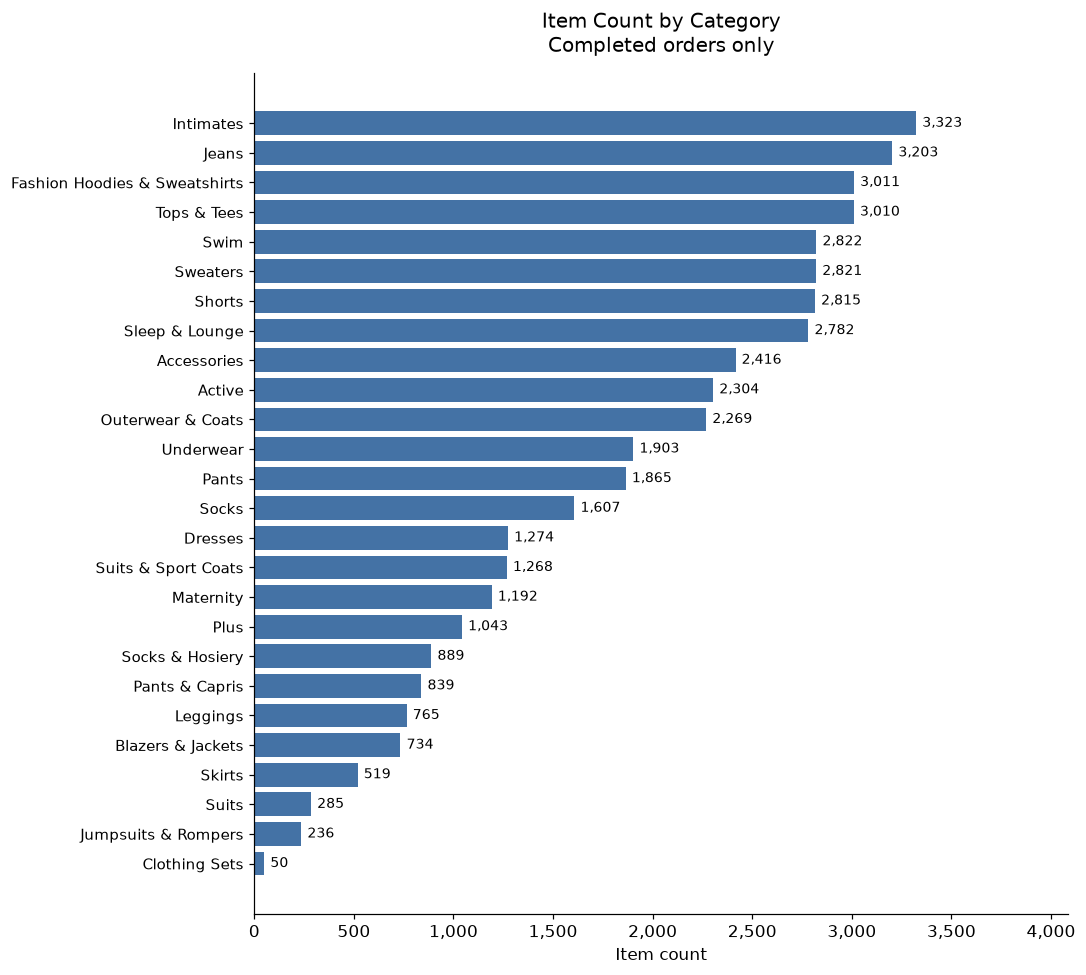

In [6]:
display(category.sort_values('gross_sales', ascending=False))
chart(category, 'category', 'gross_sales', 'Gross Sales by Category', 'gross_sales_by_category.png', horizontal=True)
chart(category, 'category', 'item_count', 'Item Count by Category', 'item_count_by_category.png', horizontal=True)

In [7]:
selected = category.set_index('category')
lines = []
for name in ['Outerwear & Coats', 'Jeans', 'Intimates']:
    row = selected.loc[name]
    lines.append(f"- **{name}**: USD {row.gross_sales:,.2f} gross sales, "
                 f"{int(row.item_count):,} items across {int(row.order_count):,} orders, "
                 f"and USD {row.avg_item_price:.2f} average item price.")
display(Markdown('\n'.join(lines) + '\n\nOuterwear & Coats has the highest gross sales, '
                 'followed by Jeans. Intimates has the highest item count but lower gross sales '
                 'and average item price. Category differences reflect both item volume and item value.'))

- **Outerwear & Coats**: USD 337,446.84 gross sales, 2,269 items across 2,219 orders, and USD 148.72 average item price.
- **Jeans**: USD 307,785.32 gross sales, 3,203 items across 3,085 orders, and USD 96.09 average item price.
- **Intimates**: USD 109,088.60 gross sales, 3,323 items across 3,110 orders, and USD 32.83 average item price.

Outerwear & Coats has the highest gross sales, followed by Jeans. Intimates has the highest item count but lower gross sales and average item price. Category differences reflect both item volume and item value.

## Price-band analysis

Analysis-defined bands use item sale price in USD: **Low <30**, **Mid 30–<80**,
and **High >=80**. These are descriptive segments, not standard pricing tiers.
Price-band order counts are non-additive because one order may contain items
from several bands. They do not measure full-basket AOV.

,price_band,item_count,order_count,gross_sales,avg_item_price,avg_items_per_order
0,Low,16508,14092,"317,156.87",19.21,1.17
1,Mid,19649,16393,"990,923.53",50.43,1.20
2,High,9088,8349,"1,393,574.76",153.34,1.09


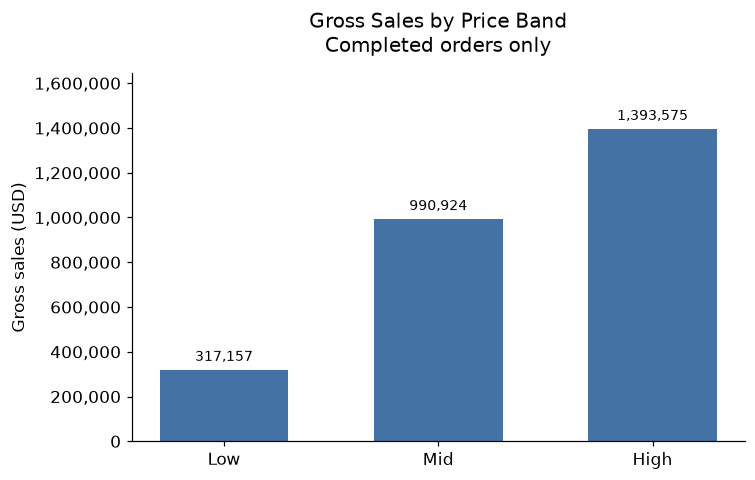

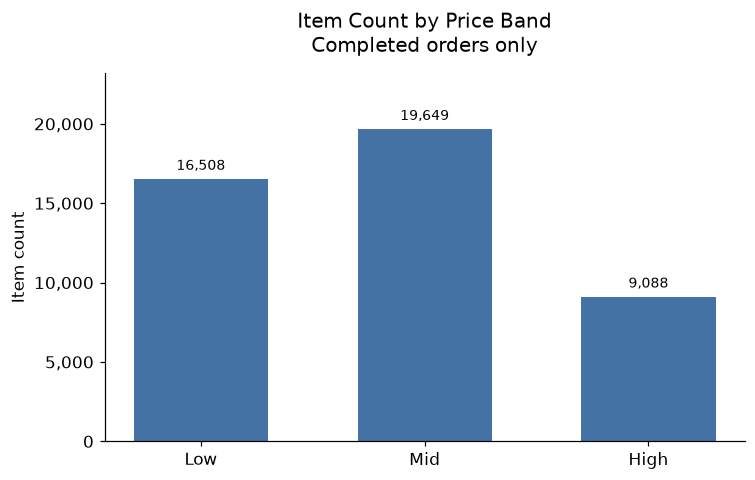

In [8]:
display(price)
chart(price, 'price_band', 'gross_sales', 'Gross Sales by Price Band', 'gross_sales_by_price_band.png')
chart(price, 'price_band', 'item_count', 'Item Count by Price Band', 'item_count_by_price_band.png')

In [9]:
high = price.set_index('price_band').loc['High']
display(Markdown(
    f"The High band generated the largest gross sales, **USD {high.gross_sales:,.2f}**, "
    f"from **{int(high.item_count):,} items**, the lowest item volume among the three bands. "
    "Mid has the highest item volume. Gross sales and item volume differ across bands alongside "
    "average item value. This comparison does not estimate the effect of changing prices or product mix."
))

The High band generated the largest gross sales, **USD 1,393,574.76**, from **9,088 items**, the lowest item volume among the three bands. Mid has the highest item volume. Gross sales and item volume differ across bands alongside average item value. This comparison does not estimate the effect of changing prices or product mix.

## Conclusion and limitations

The results do not identify a single growth lever. Separate repeat purchase
activity, item volume, and item value when interpreting gross sales. Repeat
orders have similar basket averages to first orders, while categories and price
bands combine different volumes and average item prices.

- These are descriptive aggregate comparisons, not causal estimates or strategy tests.
- First-order status is relative to the observed completed-order history.
  Cohort-based retention analysis and controlled observation windows are needed
  to compare repeat behavior over equal follow-up periods.
- Margin, costs, and profitability data are needed before making profit-based decisions.
- Aggregate consistency checks cannot establish source-row integrity, missing-price
  coverage, or category-join completeness. The repository's validation SQL needs
  a separate BigQuery run to assess those conditions.
- The existing price SQL uses `ELSE 'High'`, which also classifies NULL prices as
  High. The supplied aggregates do not expose underlying NULL-price counts.
  Review the price-band coverage validation before producing a future export.
- The public dataset can change. This notebook reproduces the supplied CSV
  snapshot only; its extraction date and observation-window bounds are unavailable.